# 15 — Compile Results: All Models

Compiles performance across all 7 ML models and 5 techniques for the 3 imbalance versions.
Generates figures 2, 3, 4, 5, and 6 for the submission / paper.

**Prerequisite:** Run all prior experiment notebooks first.

In [1]:
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc

sys.path.insert(0, os.path.abspath('..'))

RESULTS_DIR = os.path.join('..', 'results')
FIGURES_DIR = os.path.join('..', 'figures')
os.makedirs(FIGURES_DIR, exist_ok=True)
print("Compiling all results...")

Compiling all results...


In [2]:
model_files = {
    'XGBoost': {
        'Baseline': 'experiment1_baseline_xgb.csv',
        'Class Weights': 'experiment2_class_weights_xgb.csv',
        'SMOTE': 'experiment3_smote_xgb.csv',
        'Focal Loss': 'experiment4_focal_loss_xgb.csv',
        'Threshold Opt.': 'experiment5_threshold_xgb.csv'
    },
    'LightGBM': 'experiment7_lightgbm.csv',
    'Random Forest': 'experiment8_random_forest.csv',
    'CatBoost': 'experiment9_catboost.csv',
    'AdaBoost': 'experiment10_adaboost.csv',
    'Voting 3-Model': 'experiment11_voting_3model.csv',
    'Voting 4-Model': 'experiment12_voting_4model.csv'
}

compiled_rows = []

for model_name, config in model_files.items():
    if isinstance(config, dict):
        for tech_name, filename in config.items():
            path = os.path.join(RESULTS_DIR, filename)
            if os.path.exists(path):
                df = pd.read_csv(path)
                for _, row in df.iterrows():
                    compiled_rows.append({
                        'Model': model_name,
                        'Technique': tech_name,
                        'Version': row['Version'],
                        'AUC': row['AUC'],
                        'F1': row['F1'],
                        'Signal_Significance': row['Signal_Significance'],
                        'Train_Time_sec': row['Train_Time_sec']
                    })
    else:
        path = os.path.join(RESULTS_DIR, config)
        if os.path.exists(path):
            df = pd.read_csv(path)
            for _, row in df.iterrows():
                compiled_rows.append({
                    'Model': model_name,
                    'Technique': row['Technique'],
                    'Version': row['Version'],
                    'AUC': row['AUC'],
                    'F1': row['F1'],
                    'Signal_Significance': row['Signal_Significance'],
                    'Train_Time_sec': row['Train_Time_sec']
                })

df_all = pd.DataFrame(compiled_rows)
df_all.to_csv(os.path.join(RESULTS_DIR, 'all_experiments_compiled.csv'), index=False)
print(f"Compiled {len(df_all)} runs.")
print(df_all.head(10).to_string())

Compiled 105 runs.
     Model      Technique Version       AUC        F1  Signal_Significance  Train_Time_sec
0  XGBoost       Baseline       A  0.821946  0.757176           178.668317           20.76
1  XGBoost       Baseline       B  0.811544  0.230017            26.252928          405.88
2  XGBoost       Baseline       C  0.773673  0.018848             3.690886          570.82
3  XGBoost  Class Weights       A  0.821212  0.748854           178.644641          242.52
4  XGBoost  Class Weights       B  0.806582  0.373875            26.053977          608.96
5  XGBoost  Class Weights       C  0.749604  0.150767             5.388093          569.89
6  XGBoost          SMOTE       A  0.821135  0.750783           178.878019          734.38
7  XGBoost          SMOTE       B  0.761019  0.340442            24.546807          630.65
8  XGBoost          SMOTE       C  0.709420  0.116152             4.626338          446.96
9  XGBoost     Focal Loss       A  0.818397  0.767759           170.935

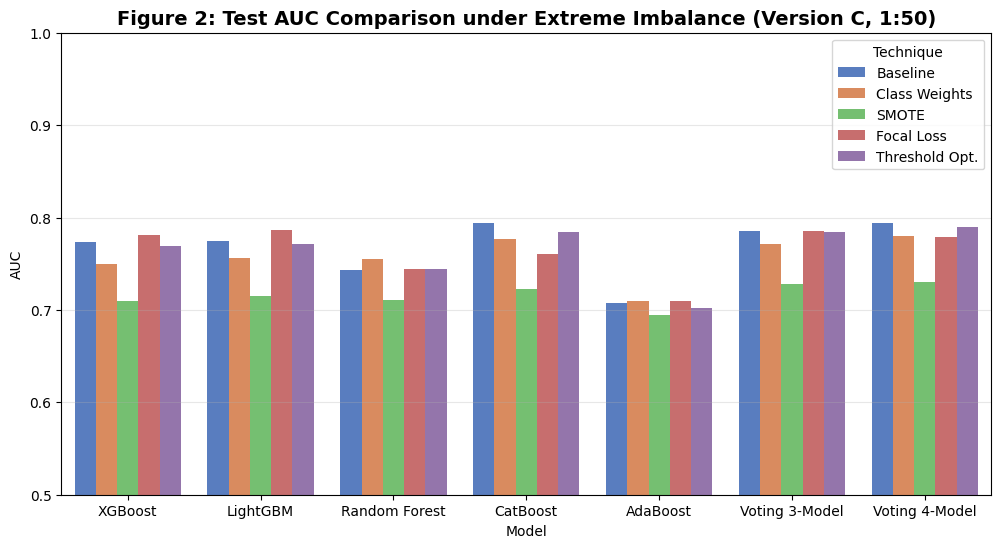

In [3]:
# Figure 2 — AUC Comparison Across Models and Techniques (Version C)
fig, ax = plt.subplots(figsize=(12, 6))
df_c = df_all[df_all['Version'] == 'C']
sns.barplot(data=df_c, x='Model', y='AUC', hue='Technique', ax=ax, palette='muted')
ax.set_title('Figure 2: Test AUC Comparison under Extreme Imbalance (Version C, 1:50)', fontsize=14, fontweight='bold')
ax.set_ylabel('AUC')
ax.set_ylim(0.5, 1.0)
ax.grid(axis='y', alpha=0.3)
plt.savefig(os.path.join(FIGURES_DIR, 'fig2_auc_comparison.png'), dpi=300, bbox_inches='tight')
plt.show()

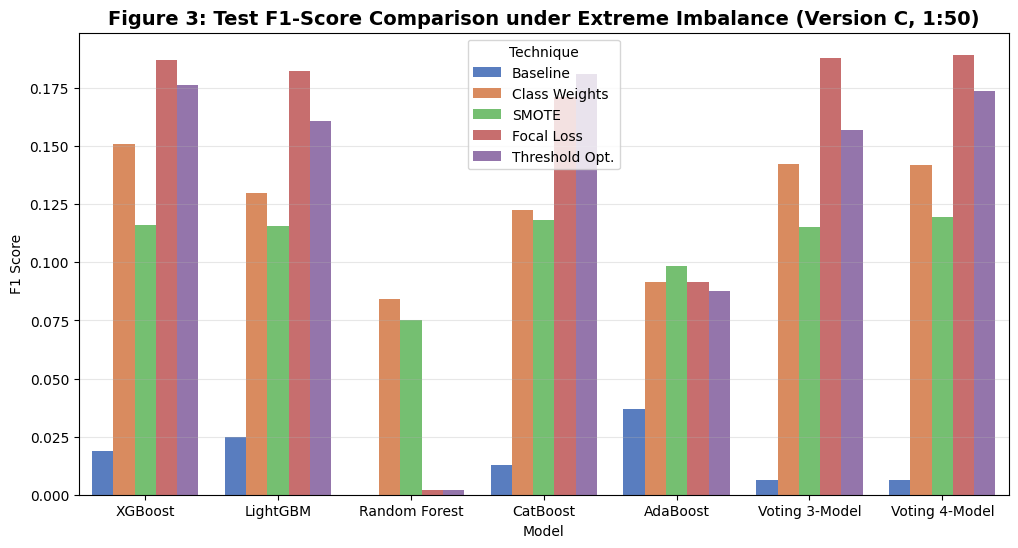

In [4]:
# Figure 3 — F1-Score Comparison Across Models and Techniques (Version C)
fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=df_c, x='Model', y='F1', hue='Technique', ax=ax, palette='muted')
ax.set_title('Figure 3: Test F1-Score Comparison under Extreme Imbalance (Version C, 1:50)', fontsize=14, fontweight='bold')
ax.set_ylabel('F1 Score')
ax.grid(axis='y', alpha=0.3)
plt.savefig(os.path.join(FIGURES_DIR, 'fig3_f1_comparison.png'), dpi=300, bbox_inches='tight')
plt.show()

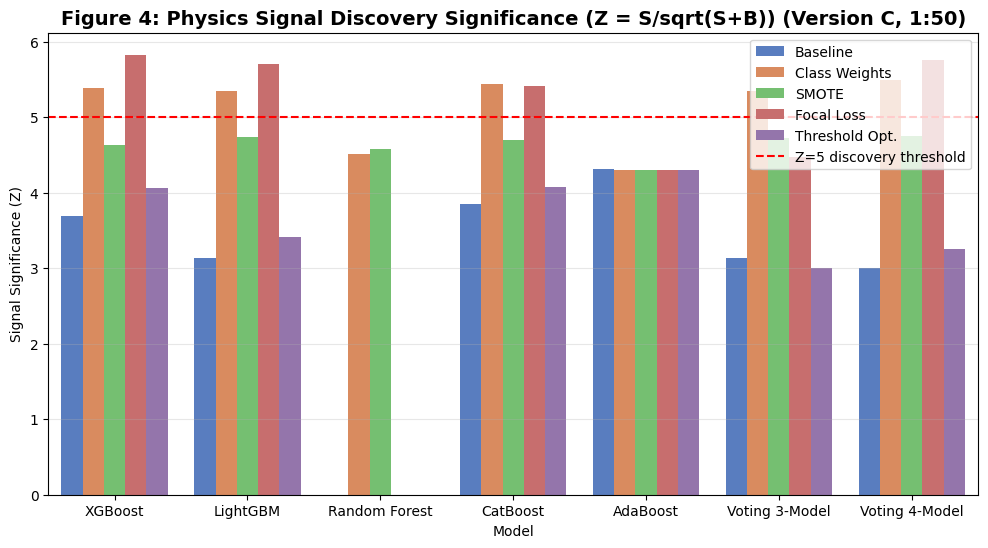

In [5]:
# Figure 4 — Signal Significance Comparison Across Models and Techniques (Version C)
fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=df_c, x='Model', y='Signal_Significance', hue='Technique', ax=ax, palette='muted')
ax.set_title('Figure 4: Physics Signal Discovery Significance (Z = S/sqrt(S+B)) (Version C, 1:50)', fontsize=14, fontweight='bold')
ax.set_ylabel('Signal Significance (Z)')
ax.axhline(y=5, color='red', linestyle='--', linewidth=1.5, label='Z=5 discovery threshold')
ax.legend(loc='upper right')
ax.grid(axis='y', alpha=0.3)
plt.savefig(os.path.join(FIGURES_DIR, 'fig4_sig_comparison.png'), dpi=300, bbox_inches='tight')
plt.show()

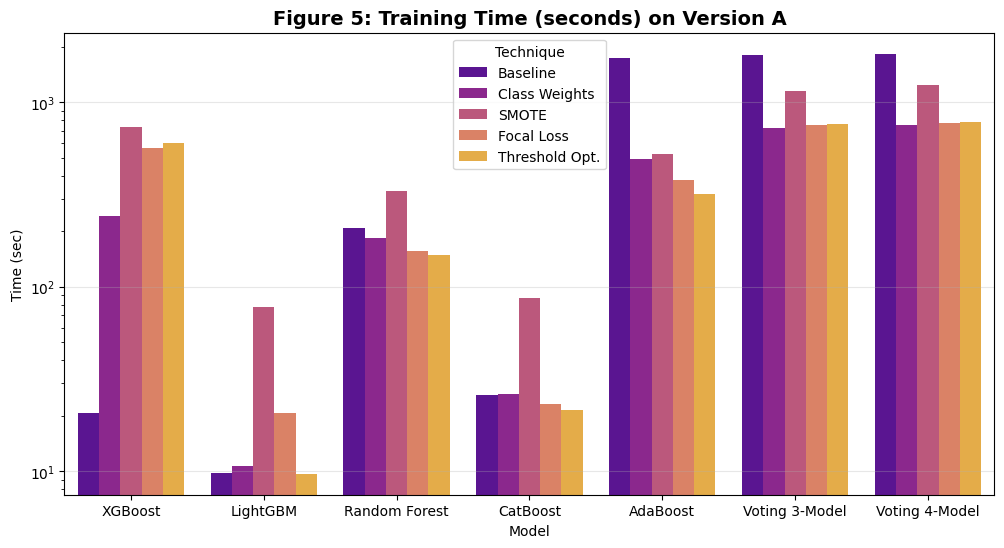

In [6]:
# Figure 5 — Training Time Comparison (Version A)
fig, ax = plt.subplots(figsize=(12, 6))
df_a = df_all[df_all['Version'] == 'A']
sns.barplot(data=df_a, x='Model', y='Train_Time_sec', hue='Technique', ax=ax, palette='plasma')
ax.set_title('Figure 5: Training Time (seconds) on Version A', fontsize=14, fontweight='bold')
ax.set_ylabel('Time (sec)')
ax.set_yscale('log')
ax.grid(axis='y', alpha=0.3)
plt.savefig(os.path.join(FIGURES_DIR, 'fig5_time_comparison.png'), dpi=300, bbox_inches='tight')
plt.show()

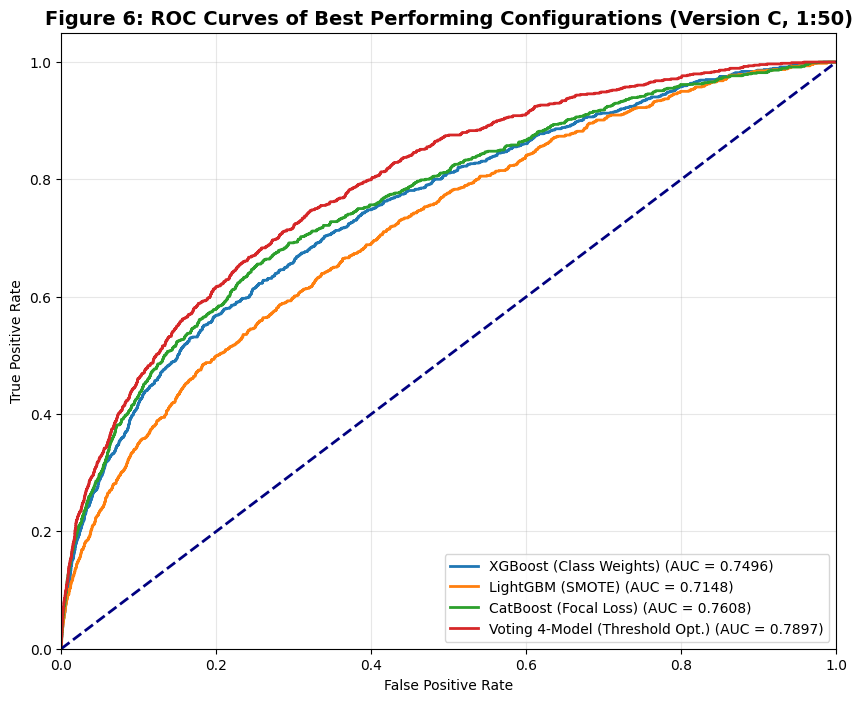

In [7]:
# Figure 6 — ROC Curves on Version C for Best Performing Configurations
plt.figure(figsize=(10, 8))
y_test = np.load(os.path.join(RESULTS_DIR, 'labels_version_C.npy'))

best_configs = [
    ('XGBoost (Class Weights)', 'probs_exp2_xgb_version_C.npy'),
    ('LightGBM (SMOTE)', 'probs_lgb_smote_version_C.npy'),
    ('CatBoost (Focal Loss)', 'probs_cb_focal_loss_version_C.npy'),
    ('Voting 4-Model (Threshold Opt.)', 'probs_voting4_threshold_version_C.npy')
]

for label, filename in best_configs:
    path = os.path.join(RESULTS_DIR, filename)
    if os.path.exists(path):
        probs = np.load(path)
        fpr, tpr, _ = roc_curve(y_test, probs)
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, lw=2, label=f'{label} (AUC = {roc_auc:.4f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Figure 6: ROC Curves of Best Performing Configurations (Version C, 1:50)', fontsize=14, fontweight='bold')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.savefig(os.path.join(FIGURES_DIR, 'fig6_roc_curves.png'), dpi=300, bbox_inches='tight')
plt.show()